In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import classification_report, precision_recall_curve, roc_auc_score, confusion_matrix
import lightgbm as lgb
import optuna
import joblib
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# 1. Load Data
df = pd.read_excel('../data/raw/E Commerce Dataset.xlsx', sheet_name='E Comm')
df = df.drop('CustomerID', axis=1, errors='ignore')

X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Rebuild Preprocessor
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object']).columns

numeric_transformer = ImbPipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = ImbPipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])
print("Data and Preprocessor ready.")

Data and Preprocessor ready.


In [ ]:
# Bayesian Optimization with Optuna for LightGBM
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'random_state': 42,
        'verbose': -1
    }
    
    lgbm = lgb.LGBMClassifier(**params)
    
    pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', lgbm)
    ])
    
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    
    return scores.mean()

print("Starting Optuna tuning (running 20 trials)...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

print("\nBest trial ROC-AUC:", study.best_value)
print("Best params:", study.best_params)
best_lgbm_params = study.best_params

[I 2026-04-21 19:56:13,514] A new study created in memory with name: no-name-8da8f71d-a3ad-433a-8573-c4be0cc1798f


Starting Optuna tuning (running 20 trials)...


[I 2026-04-21 19:56:20,875] Trial 0 finished with value: 0.93426433331292 and parameters: {'n_estimators': 232, 'learning_rate': 0.03677413195576519, 'max_depth': 4, 'min_child_samples': 39}. Best is trial 0 with value: 0.93426433331292.
[I 2026-04-21 19:56:28,315] Trial 1 finished with value: 0.9457862092904908 and parameters: {'n_estimators': 198, 'learning_rate': 0.02418240810445894, 'max_depth': 9, 'min_child_samples': 39}. Best is trial 1 with value: 0.9457862092904908.
[I 2026-04-21 19:56:35,366] Trial 2 finished with value: 0.9452515312170428 and parameters: {'n_estimators': 148, 'learning_rate': 0.09604431097655718, 'max_depth': 4, 'min_child_samples': 30}. Best is trial 1 with value: 0.9457862092904908.
[I 2026-04-21 19:56:43,912] Trial 3 finished with value: 0.9564114534906386 and parameters: {'n_estimators': 374, 'learning_rate': 0.028955325757530636, 'max_depth': 6, 'min_child_samples': 19}. Best is trial 3 with value: 0.9564114534906386.
[I 2026-04-21 19:56:51,941] Trial 4


Best trial ROC-AUC: 0.9714418378197228
Best params: {'n_estimators': 289, 'learning_rate': 0.1352818729449443, 'max_depth': 10, 'min_child_samples': 21}


In [ ]:
# Constructing the Soft Voting Classifier
# Model 1: The Baseline
lr = LogisticRegression(max_iter=1000, random_state=42)

# Model 2: The Bagging Model
rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)

# Model 3: The Tuned Boosting Model
lgbm = lgb.LGBMClassifier(**best_lgbm_params, random_state=42, verbose=-1)

# Combine into a Soft Voting Classifier
voting_clf = VotingClassifier(
    estimators=[('lr', lr), ('rf', rf), ('lgbm', lgbm)],
    voting='soft'
)

# Final complete pipeline
final_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', voting_clf)
])

print("Training the Voting Classifier on full training data...")
final_pipeline.fit(X_train, y_train)
print("Training complete.")

Training the Voting Classifier on full training data...
Training complete.


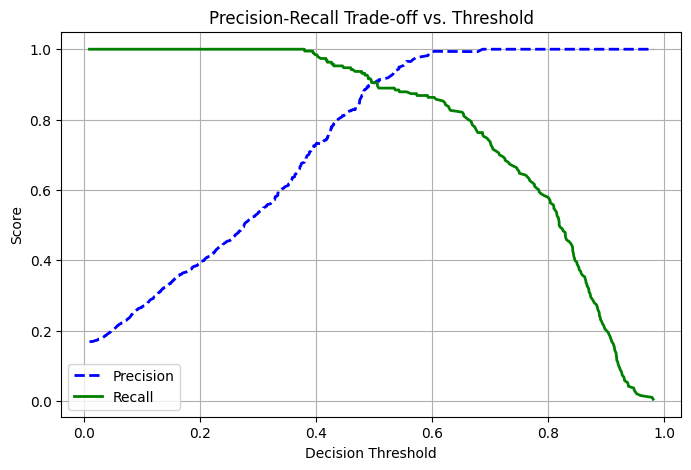

=== Results at Custom Threshold (0.35) ===
              precision    recall  f1-score   support

           0       1.00      0.87      0.93       936
           1       0.61      1.00      0.76       190

    accuracy                           0.89      1126
   macro avg       0.81      0.94      0.85      1126
weighted avg       0.93      0.89      0.90      1126


Confusion Matrix:
[[816 120]
 [  0 190]]

Caught Churners (True Positives): 190
Missed Churners (False Negatives): 0


In [ ]:
# Visualizing Precision-Recall and adjusting the threshold
# Get raw probabilities for the positive class (Churn = 1)
y_proba = final_pipeline.predict_proba(X_test)[:, 1]

# Calculate Precision-Recall curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Trade-off vs. Threshold")
plt.legend(loc="best")
plt.grid(True)
plt.show()

custom_threshold = 0.35
y_pred_custom = (y_proba >= custom_threshold).astype(int)

print(f"=== Results at Custom Threshold ({custom_threshold}) ===")
print(classification_report(y_test, y_pred_custom))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_custom)
print(cm)
print(f"\nCaught Churners (True Positives): {cm[1,1]}")
print(f"Missed Churners (False Negatives): {cm[1,0]}")

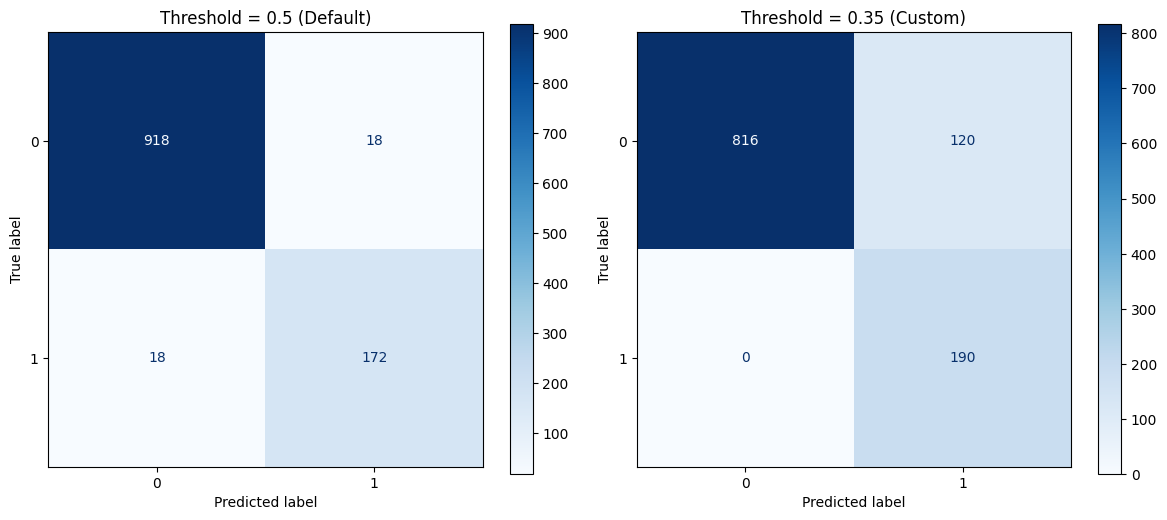

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

# Default threshold (0.5)
y_pred_default = (y_proba >= 0.5).astype(int)
cm_default = confusion_matrix(y_test, y_pred_default)

# Custom threshold (0.35)
y_pred_custom = (y_proba >= 0.35).astype(int)
cm_custom = confusion_matrix(y_test, y_pred_custom)

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(cm_default, display_labels=[0,1]).plot(ax=axes[0], cmap="Blues", values_format="d")
axes[0].set_title("Threshold = 0.5 (Default)")

ConfusionMatrixDisplay(cm_custom, display_labels=[0,1]).plot(ax=axes[1], cmap="Blues", values_format="d")
axes[1].set_title("Threshold = 0.35 (Custom)")

plt.tight_layout()
plt.show()


In [20]:
# Cell 5: SHAP Interpretability
import shap
import matplotlib.pyplot as plt

# 1. Transform the test data using our fitted preprocessor so SHAP can read it
X_test_transformed = final_pipeline.named_steps['preprocessor'].transform(X_test)

# 2. Extract feature names dynamically from the ColumnTransformer
cat_encoder = final_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
categorical_features = X_train.select_dtypes(include=['object']).columns
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns

cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)
all_feature_names = list(numeric_features) + list(cat_feature_names)



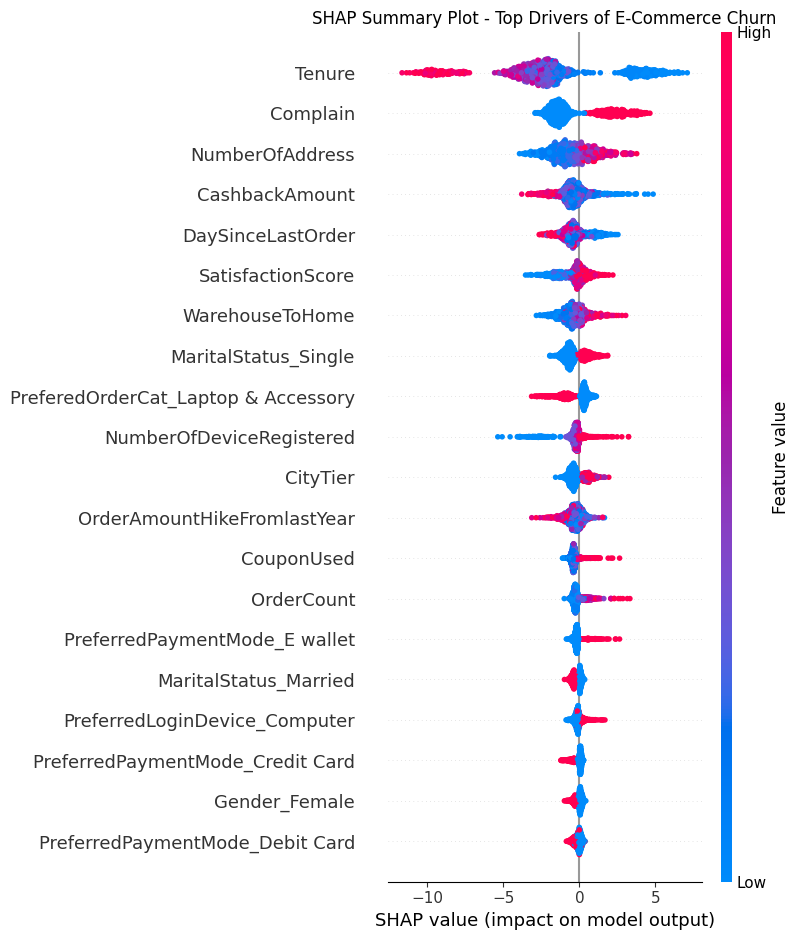

In [ ]:
# (index 2 in our VotingClassifier)
fitted_lgbm = final_pipeline.named_steps['classifier'].estimators_[2]

# Initialize the SHAP TreeExplainer
explainer = shap.TreeExplainer(fitted_lgbm)
shap_values = explainer.shap_values(X_test_transformed)

# Handle potential list output depending on SHAP/LightGBM version
shap_values_to_plot = shap_values[1] if isinstance(shap_values, list) else shap_values

# 5. Generate the Global Summary Plot
plt.figure(figsize=(10, 6))
plt.title("SHAP Summary Plot - Top Drivers of E-Commerce Churn")
shap.summary_plot(shap_values_to_plot, X_test_transformed, feature_names=all_feature_names)

In [ ]:
import joblib

import os
os.makedirs('../artifacts', exist_ok=True)

artifact_path = '../artifacts/churn_pipeline_v1.joblib'
joblib.dump(final_pipeline, artifact_path)

print(f"Success! Production pipeline saved to {artifact_path}")

Success! Production pipeline saved to ../artifacts/churn_pipeline_v1.joblib
